<a href="https://colab.research.google.com/github/Faizantinwala007/AI-Powered-Medical-Image-Analysis/blob/main/AI_Powered_Medical_Image_Analysis_System_for_Medical_Detection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**(1) MAIN TITLE **

# AI-Powered Medical Image Analysis System
# Disease Detection using Chest X-Ray Images







🔷 2. Import Libraries

In [ ]:
# Import required libraries

import numpy as np
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
# Setup Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:25<00:00, 97.1MB/s]



🔷 3. Unzip the file

In [ ]:
import zipfile

with zipfile.ZipFile("chest-xray-pneumonia.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

🔷 4. SET DATASET PATH

In [ ]:
train_path = "/content/chest_xray/train"
test_path = "/content/chest_xray/test"

print(os.listdir(train_path))  # should show NORMAL & PNEUMONIA

['NORMAL', 'PNEUMONIA']


🔷 5. Data Preprocessing

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create data generator
datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.1,
    horizontal_flip=True
)

# Training data
train_data = datagen.flow_from_directory(
    train_path,
    target_size=(256, 256),
    color_mode='grayscale',
    batch_size=32,
    class_mode='binary'
)

# Testing data
test_data = datagen.flow_from_directory(
    test_path,
    target_size=(256, 256),
    color_mode='grayscale',
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


🔷 6. BUILD MODEL

In [ ]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(256,256,1)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


🔷 7. Train Model

In [7]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=test_data
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 674s 4s/step - accuracy: 0.8154 - loss: 0.5200 - val_accuracy: 0.7356 - val_loss: 0.6736
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 661s 4s/step - accuracy: 0.9130 - loss: 0.2165 - val_accuracy: 0.7596 - val_loss: 0.8943
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 649s 4s/step - accuracy: 0.9271 - loss: 0.1934 - val_accuracy: 0.7067 - val_loss: 1.2380
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 655s 4s/step - accuracy: 0.9327 - loss: 0.1901 - val_accuracy: 0.7099 - val_loss: 1.1770
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 651s 4s/step - accuracy: 0.9419 - loss: 0.1660 - val_accuracy: 0.7276 - val_loss: 0.9547


🔷 8. Model Evaluation

In [8]:
predictions = model.predict(test_data)
predictions = (predictions > 0.5)

y_true = test_data.classes

print("Accuracy:", accuracy_score(y_true, predictions))
print("Confusion Matrix:\n", confusion_matrix(y_true, predictions))

20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step
Accuracy: 0.7163461538461539
Confusion Matrix:
 [[ 59 175]
 [  2 388]]


🔷 9. VISUALIZATION

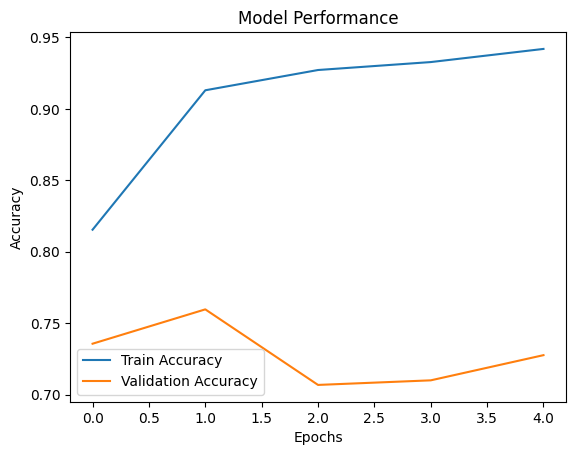

In [9]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.title("Model Performance")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()